In [ ]:
%%writefile reduction.cu

#include <stdio.h>
#include <stdlib.h>
#include <cuda.h>
#include <chrono>

using namespace std::chrono;

#define RUNS 5
#define CPU_REPEAT 10

// ================= CUDA KERNEL =================
__global__ void reduction(float *A, float *min_out, float *max_out, float *sum_out, int N) {

    __shared__ float smin[1024];
    __shared__ float smax[1024];
    __shared__ float ssum[1024];

    int tid = threadIdx.x;
    int i = blockIdx.x * blockDim.x + threadIdx.x;

    if (i < N) {
        smin[tid] = A[i];
        smax[tid] = A[i];
        ssum[tid] = A[i];
    } else {
        smin[tid] = 1e9;
        smax[tid] = -1e9;
        ssum[tid] = 0;
    }

    __syncthreads();

    for (int s = blockDim.x / 2; s > 0; s >>= 1) {
        if (tid < s) {
            smin[tid] = min(smin[tid], smin[tid + s]);
            smax[tid] = max(smax[tid], smax[tid + s]);
            ssum[tid] += ssum[tid + s];
        }
        __syncthreads();
    }

    if (tid == 0) {
        min_out[blockIdx.x] = smin[0];
        max_out[blockIdx.x] = smax[0];
        sum_out[blockIdx.x] = ssum[0];
    }
}

// ================= CPU =================
void cpu_compute(float *A, float *min_val, float *max_val, float *sum, int N) {
    *min_val = A[0];
    *max_val = A[0];
    *sum = 0;

    for (int i = 0; i < N; i++) {
        if (A[i] < *min_val) *min_val = A[i];
        if (A[i] > *max_val) *max_val = A[i];
        *sum += A[i];
    }
}

// ================= MAIN =================
int main() {

    printf("\n===== CUDA Multi-N Multi-Run GRAPH DATA (UPDATED) =====\n");

    cudaDeviceProp prop;
    cudaGetDeviceProperties(&prop, 0);

    int cores = prop.multiProcessorCount * 128;

    printf("GPU = %s\n", prop.name);
    printf("CUDA Cores (estimated) = %d\n\n", cores);

    cudaFree(0); // warm-up

    //  Increased range for better graph behavior
    int N_values[] = { 8000, 9000, 10000, 11000, 13000, 14000, 15000, 16000, 17000, 18000};
    int tests = 10;

    FILE *f = fopen("reduction_result.csv", "w");
    fprintf(f, "N,RUN,SEQ_MS,PAR_MS,SPEEDUP,EFFICIENCY,COST\n");

    for (int t = 0; t < tests; t++) {

        int N = N_values[t];
        printf("\nRunning N = %d\n", N);

        size_t size = N * sizeof(float);
        float *h_A = (float*)malloc(size);

        int threads = 1024;
        int blocks = (N + threads - 1) / threads;

        for (int r = 0; r < RUNS; r++) {

            for (int i = 0; i < N; i++)
                h_A[i] = rand() % 100;

            float *d_A, *d_min, *d_max, *d_sum;

            cudaMalloc(&d_A, size);
            cudaMalloc(&d_min, sizeof(float) * blocks);
            cudaMalloc(&d_max, sizeof(float) * blocks);
            cudaMalloc(&d_sum, sizeof(float) * blocks);

            cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);

            // ================= GPU =================
            cudaEvent_t start, stop;
            cudaEventCreate(&start);
            cudaEventCreate(&stop);

            cudaEventRecord(start);

            //  multiple launches → realistic scaling
            for (int k = 0; k < 5; k++) {
                reduction<<<blocks, threads>>>(d_A, d_min, d_max, d_sum, N);
            }

            cudaDeviceSynchronize();

            cudaEventRecord(stop);
            cudaEventSynchronize(stop);

            float par_time;
            cudaEventElapsedTime(&par_time, start, stop);

            cudaEventDestroy(start);
            cudaEventDestroy(stop);

            cudaFree(d_A);
            cudaFree(d_min);
            cudaFree(d_max);
            cudaFree(d_sum);

            // ================= CPU =================
            float total_cpu_time = 0;

            for (int i = 0; i < CPU_REPEAT; i++) {
                auto start_cpu = high_resolution_clock::now();

                float s_min, s_max, s_sum;
                cpu_compute(h_A, &s_min, &s_max, &s_sum, N);

                auto end_cpu = high_resolution_clock::now();

                total_cpu_time += duration<float, std::milli>(end_cpu - start_cpu).count();
            }

            float seq_time = total_cpu_time / CPU_REPEAT;

            float speedup = seq_time / par_time;


            float efficiency = speedup / cores;
            float cost = par_time * cores;

            // ================= SAVE =================
            fprintf(f, "%d,%d,%f,%f,%f,%f,%f\n",
                    N, r, seq_time, par_time, speedup, efficiency, cost);

            printf("Run %d | SEQ=%f ms | PAR=%f ms | SPEEDUP=%f | EFF=%f | COST=%f\n",
                   r, seq_time, par_time, speedup, efficiency, cost);
        }

        free(h_A);
    }

    fclose(f);

    printf("\nRESULT SAVED IN reduction_result.csv\n");

    return 0;
}

Overwriting reduction.cu


In [ ]:
# nvcc reduction.cu -o reduction
# ./reduction

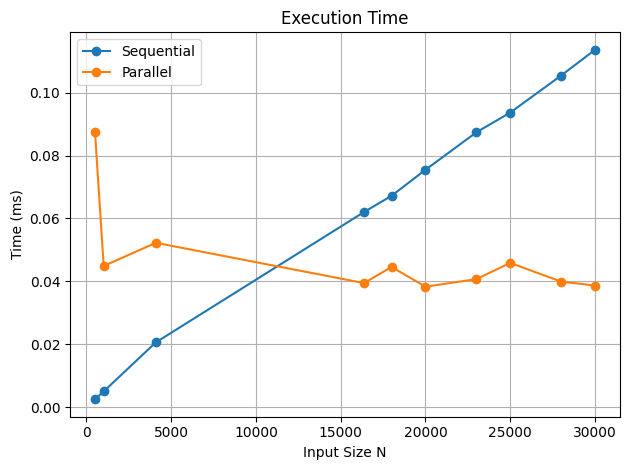

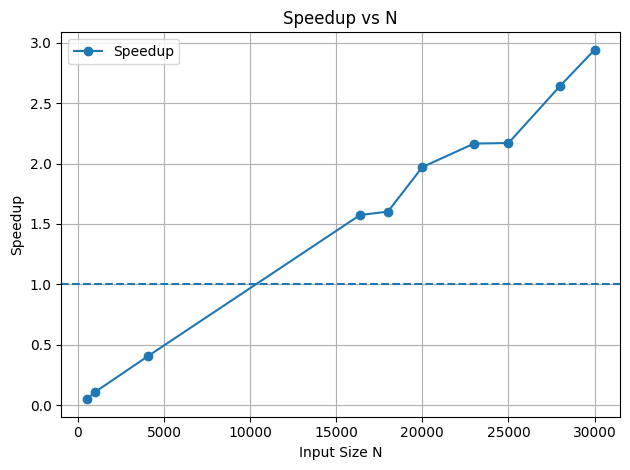

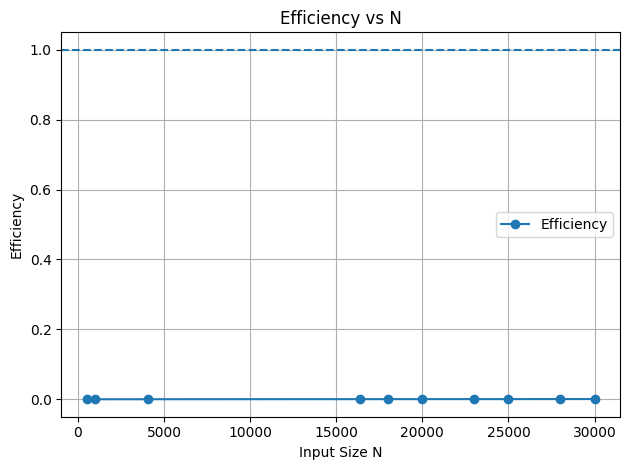

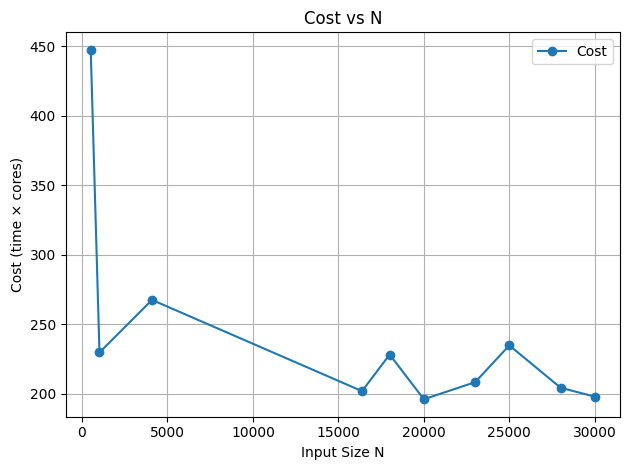

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ================= LOAD DATA =================
df = pd.read_csv("reduction_result.csv")

# Average multiple runs
df = df.groupby("N").mean().reset_index()

# Sort values
df = df.sort_values("N")

N = df["N"].values

# ================= TIME =================
plt.figure()

plt.plot(N, df["SEQ_MS"], marker='o', label="Sequential")
plt.plot(N, df["PAR_MS"], marker='o', label="Parallel")

plt.xlabel("Input Size N")
plt.ylabel("Time (ms)")
plt.title("Execution Time")

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ================= SPEEDUP =================
plt.figure()

plt.plot(N, df["SPEEDUP"], marker='o', label="Speedup")
plt.axhline(y=1, linestyle='--')

plt.xlabel("Input Size N")
plt.ylabel("Speedup")
plt.title("Speedup vs N")

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ================= EFFICIENCY =================
plt.figure()

plt.plot(N, df["EFFICIENCY"], marker='o', label="Efficiency")
plt.axhline(y=1, linestyle='--')

plt.xlabel("Input Size N")
plt.ylabel("Efficiency")
plt.title("Efficiency vs N")

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ================= COST =================
plt.figure()

plt.plot(N, df["COST"], marker='o', label="Cost")

plt.xlabel("Input Size N")
plt.ylabel("Cost (time × cores)")
plt.title("Cost vs N")

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()